In [1]:
import numpy as np
import pandas as pd
from dateutil import parser as duparser

_DT_FORMATS = [
    "%d/%m/%Y %H:%M:%S.%f",
    "%d/%m/%Y %H:%M:%S",
    "%d/%m/%Y %H:%M",
    "%Y-%m-%d %H:%M:%S.%f",
    "%Y-%m-%d %H:%M:%S",
    "%Y-%m-%d %H:%M",
    "%m/%d/%Y %H:%M:%S.%f",
    "%m/%d/%Y %H:%M:%S",
    "%m/%d/%Y %H:%M",
]

def parse_dt_series(tsraw: pd.Series) -> pd.Series:
    """
    Parse timestamps to epoch seconds without triggering pandas' 'infer format' warning.
    Tries numeric (epoch s/ms), then a set of explicit formats, then dateutil (day-first).
    """
    # 1) Numeric fast path (epoch s/ms)
    ts_num = pd.to_numeric(tsraw, errors="coerce")
    if ts_num.notna().sum() >= tsraw.notna().sum() * 0.5:
        out = ts_num.copy()
        med = out.dropna().median()
        if med and med > 1e11:  # looks like ms since epoch
            out = out / 1000.0
        return out

    # 2) Try explicit formats (vectorized, silent)
    for fmt in _DT_FORMATS:
        parsed = pd.to_datetime(tsraw, format=fmt, errors="coerce")
        if parsed.notna().mean() >= 0.80:  # good enough
            return parsed.view("int64") / 1e9  # faster than astype for datetime64[ns]

    # 3) Last-resort: dateutil per-element (silent, day-first)
    def _dparse(x):
        if pd.isna(x):
            return np.nan
        try:
            dt = duparser.parse(str(x), dayfirst=True, fuzzy=True)
            return dt.timestamp()
        except Exception:
            return np.nan

    return tsraw.apply(_dparse).astype(float)


In [3]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="Could not infer format, so each element will be parsed individually",
    category=UserWarning,
    module="pandas"
)

In [5]:
# ==============================================================
# Baseline Builder: iot_gateway_nids  (IoT-23 Zeek + GHOST CSV + HomeNet CSV)
# Output: baselines/iot_gateway_nids_baseline_YYYYMMDD.yaml
# Deps: pandas numpy pyyaml
# ==============================================================

import os, glob, codecs
from datetime import datetime
from typing import List, Optional, Dict
import numpy as np
import pandas as pd
import yaml

# ---------------------------
# CONFIG — EDIT THESE PATHS
# ---------------------------
IOT23_GLOBS   = [r"E:/iot23_v2_benign/*.labeled"]  # IoT-23 v2 benign Zeek logs
GHOST_GLOBS   = [r"E:/ghost/*.csv"]                              # GHOST CSVs
HOMENET_GLOBS = [r"E:/homenet/*.csv"]                            # UNSW HomeNet CSVs

PROFILE_NAME = "iot_gateway_nids"
OUT_DIR      = "baselines"

# Tunables
N_BINS       = 50
WINSOR       = (0.005, 0.995)
BURST_WIN_S  = 10
INCLUDE_TEMPORAL  = True   # include IAT/Fano/Diurnal if timestamps exist
INCLUDE_PROXY_IAT = True   # include within-flow IAT mean (if present)

# ---------------------------
# Utilities
# ---------------------------
def _match_paths(pattern: str):
    if os.path.isfile(pattern):
        return [pattern]
    return glob.glob(pattern, recursive=True)

def _ci(df):  # case-insensitive lookup dict
    return {str(c).lower().strip(): c for c in df.columns}

def _series(n, v):
    return pd.Series([v]*n)

def _safe_num(s):
    return pd.to_numeric(s, errors="coerce")

def _winsorize(series: pd.Series, q_low=0.005, q_high=0.995) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").dropna().astype(float)
    if s.empty: return s
    lo, hi = s.quantile([q_low, q_high])
    return s.clip(lower=lo, upper=hi)

def _log10_hist_cdf(series: pd.Series, n_bins=N_BINS):
    s = _winsorize(series, *WINSOR)
    s = s[s>0]
    if s.empty: return [], []
    logv = np.log10(s.values)
    hist, edges = np.histogram(logv, bins=n_bins, density=True)
    cdf = np.cumsum(hist)/np.sum(hist)
    return edges.tolist(), cdf.tolist()

def _normalize_proto(v):
    v = str(v).strip().lower()
    if v in ("6","tcp"): return "tcp"
    if v in ("17","udp"): return "udp"
    if v in ("1","icmp"): return "icmp"
    return v or "unknown"

def _mix(series: Optional[pd.Series]):
    if series is None: return None
    s = series.dropna().astype(str).str.lower()
    s = s[(s!='-') & (s!='none')]
    vc = s.value_counts()
    if vc.sum()==0: return None
    return (vc / vc.sum()).to_dict()

# Ports → service (extend as needed for IoT)
_PORT2SVC = {
    53:"dns", 80:"http", 443:"https", 123:"ntp",
    20:"ftp-data", 21:"ftp", 22:"ssh", 23:"telnet", 25:"smtp",
    110:"pop3", 143:"imap", 69:"tftp", 161:"snmp",
    995:"pop3s", 993:"imaps", 587:"submission", 8080:"http-alt",
    3306:"mysql", 3389:"rdp", 5060:"sip", 5353:"mdns",
    1900:"ssdp", 554:"rtsp", 8883:"mqtts", 1883:"mqtt"
}
def infer_service_from_port(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.map(lambda x: _PORT2SVC.get(int(x), None) if pd.notna(x) else None)

# ---------------------------
# Hardened Zeek conn.log(.labeled) parser (no pandas.read_csv)
# ---------------------------
def _decode_zeek_separator(tok: str) -> str:
    # Zeek writes "#separator \x09" (tab). Decode escapes.
    tok = tok.strip()
    try:
        return codecs.decode(tok.encode('utf-8').decode('unicode_escape'), 'unicode_escape')
    except Exception:
        return "\t"

def read_zeek_conn_manual(path: str) -> pd.DataFrame:
    sep = "\t"
    fields = None
    rows = []
    with open(path, "r", errors="ignore", newline="") as f:
        for line in f:
            if not line:
                continue
            if line.startswith("#separator"):
                parts = line.strip().split(maxsplit=1)
                if len(parts) == 2:
                    sep = _decode_zeek_separator(parts[1])
                continue
            if line.startswith("#fields"):
                # "#fields ts uid id.orig_h id.orig_p id.resp_h id.resp_p proto service ..."
                parts = line.strip().split()
                fields = parts[1:]
                continue
            if line.startswith("#"):
                continue
            # data row
            vals = line.rstrip("\n").split(sep) if fields else line.rstrip("\n").split()
            if fields and len(vals) != len(fields):
                # fallback split on whitespace if separator mismatch
                vals = line.rstrip("\n").split()
            rows.append(vals)
    if not rows:
        return pd.DataFrame(columns=fields or [])
    if fields:
        L = len(fields)
        rows = [r[:L] + [""]*(L-len(r)) if len(r) < L else r[:L] for r in rows]
        return pd.DataFrame(rows, columns=fields, dtype=str)
    return pd.DataFrame(rows, dtype=str)

def norm_zeek_conn(df: pd.DataFrame) -> pd.DataFrame:
    nm = _ci(df); n = len(df); col = lambda x: nm.get(x.lower())
    ts = col("ts"); proto = col("proto"); service = col("service")
    ob = col("orig_bytes"); rb = col("resp_bytes")
    op = col("orig_pkts");  rp = col("resp_pkts")
    dur = col("duration")

    start_ts = _safe_num(df[ts]) if ts else _series(n, np.nan)
    bytes_v  = (_safe_num(df[ob]).fillna(0) if ob else 0) + (_safe_num(df[rb]).fillna(0) if rb else 0)
    pkts_v   = (_safe_num(df[op]).fillna(0) if op else 0) + (_safe_num(df[rp]).fillna(0) if rp else 0)
    duration = _safe_num(df[dur]) if dur else _series(n, np.nan)
    proto_v  = df[proto].astype(str).map(_normalize_proto) if proto else _series(n, "unknown")
    service_v= df[service].astype(str).str.lower() if service else _series(n, None)
    service_v= service_v.where(~service_v.isin(["-",""]), other=None)

    return pd.DataFrame({
        "bytes":bytes_v, "pkts":pkts_v, "duration":duration,
        "start_ts":start_ts, "proto":proto_v, "service":service_v
    }).replace([np.inf,-np.inf], np.nan)

# ---------------------------
# Flexible CSV normalizer (GHOST / HomeNet)
# → bytes, pkts, duration(s), start_ts(s epoch), proto, service, flow_iat_mean_vals(optional)
# ---------------------------
def _first_present(nm: Dict[str,str], *cands):
    for c in cands:
        got = nm.get(c.lower())
        if got: return got
    return None

def norm_flex_flow_csv(df: pd.DataFrame) -> pd.DataFrame:
    nm = _ci(df); n=len(df)

    # bytes (allow 2-sided sum if separate)
    b1 = _first_present(nm, "bytes","total bytes","tot bytes","total_length","len","length",
                        "TotLen Fwd Pkts","Total Length of Fwd Packets")
    b2 = _first_present(nm, "dbytes","dst bytes","Total Length of Bwd Packets","TotLen Bwd Pkts")
    if b1 and b2 and b1!=b2:
        bytes_v = _safe_num(df[b1]).fillna(0) + _safe_num(df[b2]).fillna(0)
    elif b1:
        bytes_v = _safe_num(df[b1])
    else:
        bytes_v = _series(n, np.nan)

    # pkts
    p1 = _first_present(nm, "pkts","packets","total packets","Tot Fwd Pkts","Total Fwd Packets")
    p2 = _first_present(nm, "dpkts","dst pkts","Tot Bwd Pkts","Total Backward Packets")
    if p1 and p2 and p1!=p2:
        pkts_v = _safe_num(df[p1]).fillna(0) + _safe_num(df[p2]).fillna(0)
    elif p1:
        pkts_v = _safe_num(df[p1])
    else:
        pkts_v = _series(n, np.nan)

    # duration (s; convert if looks like microseconds)
    dcol = _first_present(nm, "duration","flow duration","time","dur")
    duration = _safe_num(df[dcol]) if dcol else _series(n, np.nan)
    if duration.dropna().median() and duration.dropna().median() > 1e5:
        duration = duration/1e6

    # start_ts: numeric epoch (ms/s) or datetime strings → epoch s
    tcol = _first_present(nm, "ts","start","start_time","timestamp","stime","time_start","flow start")
    if tcol:
        tsraw = df[tcol]
        ts_num = _safe_num(tsraw)
        if ts_num.notna().sum() >= tsraw.notna().sum()*0.5:
            start_ts = ts_num
            med = start_ts.dropna().median()
            if med and med > 1e11:  # ms
                start_ts = start_ts/1000.0
        else:
            start_ts = parse_dt_series(tsraw)
    else:
        start_ts = _series(n, np.nan)

    # protocol
    pcol = _first_present(nm, "protocol","proto")
    proto = df[pcol].astype(str).map(_normalize_proto) if pcol else _series(n, "unknown")

    # service from dest port
    dport = _first_present(nm, "dst_port","dport","destination port","responp","dest port")
    service = infer_service_from_port(df[dport]) if dport else _series(n, None)

    # temporal proxy (within-flow IAT mean)
    iat_mean_col = _first_present(nm, "flow iat mean","flow_iat.mean","flow_iat.avg","Flow IAT Mean","flow_iat_avg")
    flow_iat_mean_vals = _safe_num(df[iat_mean_col]) if iat_mean_col else _series(n, np.nan)

    return pd.DataFrame({
        "bytes":bytes_v, "pkts":pkts_v, "duration":duration,
        "start_ts":start_ts, "proto":proto, "service":service,
        "flow_iat_mean_vals": flow_iat_mean_vals
    }).replace([np.inf,-np.inf], np.nan)

# ---------------------------
# Load all sources
# ---------------------------
def load_iot_sources(iot23_globs: List[str], ghost_globs: List[str], homenet_globs: List[str]) -> pd.DataFrame:
    frames = []

    # IoT-23 Zeek logs
    for g in iot23_globs:
        for p in _match_paths(g):
            try:
                df_raw = read_zeek_conn_manual(p)
                frames.append(norm_zeek_conn(df_raw))
            except Exception as e:
                print("[WARN IoT-23]", p, e)

    # GHOST CSVs
    for g in ghost_globs:
        for p in _match_paths(g):
            try:
                df_raw = pd.read_csv(p, low_memory=False, compression="infer")
                frames.append(norm_flex_flow_csv(df_raw))
            except Exception as e:
                print("[WARN GHOST]", p, e)

    # HomeNet CSVs
    for g in homenet_globs:
        for p in _match_paths(g):
            try:
                df_raw = pd.read_csv(p, low_memory=False, compression="infer")
                frames.append(norm_flex_flow_csv(df_raw))
            except Exception as e:
                print("[WARN HomeNet]", p, e)

    if not frames:
        raise FileNotFoundError("No files loaded. Check your globs and paths.")
    flows = pd.concat(frames, ignore_index=True).replace([np.inf,-np.inf], np.nan)

    # basic cleanup
    for c in ["bytes","pkts","duration","start_ts"]:
        if c in flows.columns:
            flows[c] = _safe_num(flows[c])

    # normalize proto values once more
    if "proto" in flows.columns:
        flows["proto"] = flows["proto"].astype(str).map(_normalize_proto)

    return flows

# ---------------------------
# Extract baseline metrics
# ---------------------------
def extract_baseline_metrics(flows: pd.DataFrame,
                             n_bins=N_BINS,
                             include_temporal=INCLUDE_TEMPORAL,
                             include_proxy_iat=INCLUDE_PROXY_IAT,
                             burst_win_s=BURST_WIN_S):
    # Volume CDFs
    bins_b, cdf_b = _log10_hist_cdf(flows["bytes"], n_bins)
    bins_p, cdf_p = _log10_hist_cdf(flows["pkts"],  n_bins)
    bins_d, cdf_d = _log10_hist_cdf(flows["duration"], n_bins)

    metrics = {
        "bytes_per_flow": {"bins_log10": bins_b, "cdf": cdf_b},
        "pkts_per_flow":  {"bins_log10": bins_p, "cdf": cdf_p},
        "flow_duration":  {"bins_log10": bins_d, "cdf": cdf_d},
    }

    # Protocol / Service mix
    metrics["protocol_mix"] = _mix(flows.get("proto"))
    if "service" in flows.columns:
        metrics["service_mix"] = _mix(flows.get("service"))

    # Temporal (inter-flow IAT, Fano, diurnal)
    if include_temporal and "start_ts" in flows.columns:
        ts = pd.to_numeric(flows["start_ts"], errors="coerce").dropna()
        if not ts.empty:
            ts_sorted = ts.sort_values()
            iat = ts_sorted.diff().dropna(); iat = iat[iat > 0]
            if not iat.empty:
                i_bins, i_cdf = _log10_hist_cdf(iat, n_bins)
                metrics["iat_flows"] = {"bins_log10": i_bins, "cdf": i_cdf}
            # Fano (burstiness)
            t0 = ts_sorted.min()
            buckets = np.floor((ts_sorted - t0) / burst_win_s).astype(int)
            counts = pd.Series(1, index=buckets).groupby(level=0).sum().astype(float)
            lam = counts.mean(); var = counts.var(ddof=0)
            if lam and lam > 0:
                metrics["burstiness"] = {"fano_ref": float(var/lam), "window_s": int(burst_win_s)}
            # Diurnal shape (hourly)
            hours = pd.to_datetime(ts_sorted, unit="s").dt.hour
            hcounts = hours.value_counts().reindex(range(24), fill_value=0).astype(float)
            if hcounts.sum() > 0:
                metrics["diurnal_shape_hourly"] = [float(x) for x in (hcounts/hcounts.sum()).tolist()]

    # Temporal proxy (within-flow IAT mean)
    if include_proxy_iat and "flow_iat_mean_vals" in flows.columns:
        vals = pd.to_numeric(flows["flow_iat_mean_vals"], errors="coerce").dropna()
        if not vals.empty:
            p_bins, p_cdf = _log10_hist_cdf(vals, n_bins)
            metrics["flow_iat_mean"] = {"bins_log10": p_bins, "cdf": p_cdf}

    # drop empty entries
    metrics = {k:v for k,v in metrics.items() if v and (not isinstance(v, dict) or any((vv for vv in v.values())))}
    return metrics

# ---------------------------
# Build & write baseline
# ---------------------------
def build_iot_gateway_baseline(iot23_globs=IOT23_GLOBS,
                               ghost_globs=GHOST_GLOBS,
                               homenet_globs=HOMENET_GLOBS,
                               profile_name=PROFILE_NAME,
                               out_dir=OUT_DIR):
    os.makedirs(out_dir, exist_ok=True)
    flows = load_iot_sources(iot23_globs, ghost_globs, homenet_globs)

    # Basic hygiene
    flows = flows[(flows["bytes"]>=0) & (flows["pkts"]>=0) & (flows["duration"]>=0)]
    # If services are all None, try inferring from any alt port column (best-effort)
    if "service" in flows.columns and flows["service"].isna().all():
        for cand in ["dport","dst_port","destination port","responp","dest port"]:
            ci = _ci(flows)
            if cand in ci:
                flows["service"] = infer_service_from_port(flows[ci[cand]])
                break

    print(f"[INFO] Total flows ingested: {len(flows):,}")
    if len(flows) < 1000:
        print("[WARN] Very few flows; consider adding more days/sources for a stable baseline.")

    metrics = extract_baseline_metrics(flows)
    baseline = {
        "profile": profile_name,
        "version": datetime.utcnow().strftime("%Y-%m-%d"),
        "sources": {
            "iot23_files": sum([len(_match_paths(g)) for g in iot23_globs]),
            "ghost_files": sum([len(_match_paths(g)) for g in ghost_globs]),
            "homenet_files": sum([len(_match_paths(g)) for g in homenet_globs]),
            "total_flows": int(len(flows))
        },
        "metrics": metrics
    }

    out_path = os.path.join(out_dir, f"{profile_name}_baseline_{baseline['version'].replace('-','')}.yaml")
    with open(out_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(baseline, f, sort_keys=False)
    print("Baseline written to:", out_path)
    return out_path

# ---------------------------
# RUN
# ---------------------------
_ = build_iot_gateway_baseline()


C:\Users\ifrah\AppData\Local\Temp\ipykernel_13164\1163384528.py:35: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  return parsed.view("int64") / 1e9  # faster than astype for datetime64[ns]
C:\Users\ifrah\AppData\Local\Temp\ipykernel_13164\1163384528.py:35: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  return parsed.view("int64") / 1e9  # faster than astype for datetime64[ns]


[INFO] Total flows ingested: 370,909
Baseline written to: baselines\iot_gateway_nids_baseline_20250925.yaml


Profile: iot_gateway_nids Version: 2025-09-25
Sources: {'iot23_files': 12, 'ghost_files': 12, 'homenet_files': 6, 'total_flows': 370909}
Metric keys: ['bytes_per_flow', 'pkts_per_flow', 'flow_duration', 'protocol_mix', 'service_mix', 'iat_flows', 'burstiness', 'diurnal_shape_hourly']

Top protocols: [('tcp', 0.8694908993850243), ('udp', 0.1252921875716146), ('icmp', 0.00521691304336104)]
Top services: [('ssh', 0.3898618729760095), ('ntp', 0.3151807547419206), ('http', 0.22833917123785605), ('dns', 0.04897230850571674), ('dhcp', 0.01136739144802062), ('ssl', 0.0058819641794990414), ('irc', 0.0003965369109774635)]

bytes_per_flow bins_log10 (first 6): [0.0, 0.0690357287104858, 0.1380714574209716, 0.2071071861314574, 0.2761429148419432, 0.345178643552429]
bytes_per_flow cdf        (first 6): [0.00012556701354554146, 0.00012556701354554146, 0.00012556701354554146, 0.00012556701354554146, 0.00012556701354554146, 0.00012556701354554146]


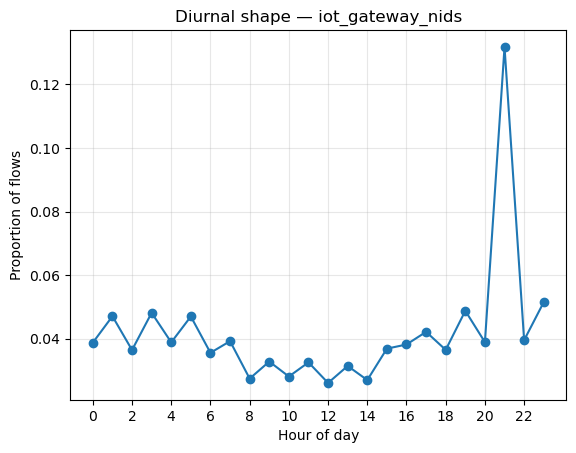

In [7]:
import yaml, numpy as np, matplotlib.pyplot as plt

BL = r"baselines/iot_gateway_nids_baseline_20250925.yaml"  # <- your file

with open(BL, "r", encoding="utf-8") as f:
    b = yaml.safe_load(f)

print("Profile:", b["profile"], "Version:", b["version"])
print("Sources:", b.get("sources", {}))
M = b["metrics"]
print("Metric keys:", list(M.keys()))

# Top protocols/services
def topk(d, k=10):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:k]

if "protocol_mix" in M:
    print("\nTop protocols:", topk(M["protocol_mix"]))
if "service_mix" in M:
    print("Top services:", topk(M["service_mix"]))

# Quick CDF peek: bytes per flow (first 6 points)
if "bytes_per_flow" in M:
    print("\nbytes_per_flow bins_log10 (first 6):", M["bytes_per_flow"]["bins_log10"][:6])
    print("bytes_per_flow cdf        (first 6):", M["bytes_per_flow"]["cdf"][:6])

# Diurnal plot
if "diurnal_shape_hourly" in M:
    di = np.array(M["diurnal_shape_hourly"], dtype=float)
    plt.figure()
    plt.plot(range(24), di, marker="o")
    plt.xticks(range(0,24,2))
    plt.xlabel("Hour of day")
    plt.ylabel("Proportion of flows")
    plt.title("Diurnal shape — iot_gateway_nids")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("\n[Note] No diurnal_shape_hourly in baseline (insufficient or missing start_ts).")


In [1]:
import os, glob, codecs
from datetime import datetime
from typing import List, Optional, Dict

import numpy as np
import pandas as pd
import yaml
from dateutil import parser as duparser
import warnings
warnings.filterwarnings("ignore",
    message="Could not infer format, so each element will be parsed individually",
    category=UserWarning, module="pandas")

# ---------------------------
# CONFIG
# ---------------------------
IOT23_GLOBS   = [r"E:/iot23_v2_benign/*.labeled"]   # IoT-23 v2 Zeek conn logs (benign)
GHOST_GLOBS   = [r"E:/ghost/*.csv"]                 # GHOST CSVs
HOMENET_GLOBS = [r"E:/homenet/*.csv"]               # UNSW HomeNet CSVs

PROFILE_NAME = "iot_gateway_nids"
OUT_DIR      = "baselines"

N_BINS      = 50
WINSOR      = (0.005, 0.995)
BURST_WIN_S = 10
INCLUDE_TEMPORAL  = True
INCLUDE_PROXY_IAT = True

# ---------------------------
# Date parsing (hardened)
# ---------------------------
_DT_FORMATS = [
    "%d/%m/%Y %H:%M:%S.%f","%d/%m/%Y %H:%M:%S","%d/%m/%Y %H:%M",
    "%Y-%m-%d %H:%M:%S.%f","%Y-%m-%d %H:%M:%S","%Y-%m-%d %H:%M",
    "%m/%d/%Y %H:%M:%S.%f","%m/%d/%Y %H:%M:%S","%m/%d/%Y %H:%M",
]

def parse_dt_series(tsraw: pd.Series) -> pd.Series:
    ts_num = pd.to_numeric(tsraw, errors="coerce")
    if ts_num.notna().sum() >= tsraw.notna().sum()*0.5:
        out = ts_num.copy()
        med = out.dropna().median()
        if med and med > 1e11:  # ms → s
            out = out/1000.0
        return out
    for fmt in _DT_FORMATS:
        parsed = pd.to_datetime(tsraw, format=fmt, errors="coerce", utc=True)
        if parsed.notna().mean() >= 0.80:
            return parsed.view("int64")/1e9
    def _dparse(x):
        if pd.isna(x): return np.nan
        try:
            return duparser.parse(str(x), dayfirst=True, fuzzy=True).timestamp()
        except Exception:
            return np.nan
    return tsraw.apply(_dparse).astype(float)

# ---------------------------
# Helpers
# ---------------------------
def _match_paths(pattern: str):
    return [pattern] if os.path.isfile(pattern) else glob.glob(pattern, recursive=True)

def _ci(df):  # case-insensitive lookup
    return {str(c).lower().strip(): c for c in df.columns}

def _series(n, v): return pd.Series([v]*n)

def _safe_num(s): return pd.to_numeric(s, errors="coerce")

def _winsorize(series: pd.Series, q_low=WINSOR[0], q_high=WINSOR[1]) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").dropna().astype(float)
    if s.empty: return s
    lo, hi = s.quantile([q_low, q_high])
    return s.clip(lower=lo, upper=hi)

def _log10_hist_cdf(series: pd.Series, n_bins=N_BINS):
    s = _winsorize(series)
    s = s[s>0]
    if s.empty: return [], []
    logv = np.log10(s.values)
    hist, edges = np.histogram(logv, bins=n_bins, density=True)
    if np.sum(hist) == 0:
        return edges.tolist(), [0.0]*(len(edges)-1)
    cdf = np.cumsum(hist)/np.sum(hist)
    return edges.tolist(), cdf.tolist()

def _normalize_proto(v):
    v = str(v).strip().lower()
    if v in ("6","tcp"): return "tcp"
    if v in ("17","udp"): return "udp"
    if v in ("1","icmp"): return "icmp"
    return v or "unknown"

def _mix(series: Optional[pd.Series]):
    if series is None: return None
    s = series.dropna().astype(str).str.lower()
    s = s[(s!='-') & (s!='none') & (s!='')]
    vc = s.value_counts()
    if vc.sum()==0: return None
    return (vc / vc.sum()).to_dict()

# Ports → service (common IoT + infra)
_PORT2SVC = {
    53:"dns", 80:"http", 443:"https", 123:"ntp",
    20:"ftp-data", 21:"ftp", 22:"ssh", 23:"telnet", 25:"smtp",
    110:"pop3", 143:"imap", 69:"tftp", 161:"snmp",
    995:"pop3s", 993:"imaps", 587:"submission", 8080:"http-alt",
    3306:"mysql", 3389:"rdp", 5060:"sip", 5353:"mdns",
    1900:"ssdp", 554:"rtsp", 8883:"mqtts", 1883:"mqtt"
}
def infer_service_from_port(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.map(lambda x: _PORT2SVC.get(int(x), None) if pd.notna(x) else None)

# ---------------------------
# Zeek conn.labeled reader (manual; robust to separators)
# ---------------------------
def _decode_zeek_separator(tok: str) -> str:
    tok = tok.strip()
    try:
        return codecs.decode(tok.encode('utf-8').decode('unicode_escape'), 'unicode_escape')
    except Exception:
        return "\t"

def read_zeek_conn_manual(path: str) -> pd.DataFrame:
    sep = "\t"; fields = None; rows = []
    with open(path, "r", errors="ignore", newline="") as f:
        for line in f:
            if not line: continue
            if line.startswith("#separator"):
                parts = line.strip().split(maxsplit=1)
                if len(parts)==2: sep = _decode_zeek_separator(parts[1]); continue
            if line.startswith("#fields"):
                parts = line.strip().split()
                fields = parts[1:]; continue
            if line.startswith("#"): continue
            vals = line.rstrip("\n").split(sep) if fields else line.rstrip("\n").split()
            if fields and len(vals)!=len(fields):
                vals = line.rstrip("\n").split()
            rows.append(vals)
    if not rows: return pd.DataFrame(columns=fields or [])
    if fields:
        L=len(fields)
        rows = [r[:L]+[""]*(L-len(r)) if len(r)<L else r[:L] for r in rows]
        return pd.DataFrame(rows, columns=fields, dtype=str)
    return pd.DataFrame(rows, dtype=str)

def norm_zeek_conn(df: pd.DataFrame) -> pd.DataFrame:
    nm = _ci(df); n = len(df); col = lambda x: nm.get(x.lower())
    ts = col("ts"); proto = col("proto"); service = col("service")
    ob = col("orig_bytes"); rb = col("resp_bytes")
    op = col("orig_pkts");  rp = col("resp_pkts")
    dur = col("duration")
    resp_p = col("id.resp_p") or col("resp_p")  # NEW: for service inference

    start_ts = _safe_num(df[ts]) if ts else _series(n, np.nan)
    bytes_v  = (_safe_num(df[ob]).fillna(0) if ob else 0) + (_safe_num(df[rb]).fillna(0) if rb else 0)
    pkts_v   = (_safe_num(df[op]).fillna(0) if op else 0) + (_safe_num(df[rp]).fillna(0) if rp else 0)
    duration = _safe_num(df[dur]) if dur else _series(n, np.nan)
    proto_v  = df[proto].astype(str).map(_normalize_proto) if proto else _series(n, "unknown")

    # service: prefer Zeek's 'service'; backfill from responder port if missing/'-'
    if service:
        service_v = df[service].astype(str).str.lower()
        if resp_p:
            inferred = infer_service_from_port(df[resp_p])
            service_v = service_v.where(~service_v.isin(["-","none","",None]), inferred)
    else:
        service_v = infer_service_from_port(df[resp_p]) if resp_p else _series(n, None)

    return pd.DataFrame({
        "bytes":bytes_v, "pkts":pkts_v, "duration":duration,
        "start_ts":start_ts, "proto":proto_v, "service":service_v
    }).replace([np.inf,-np.inf], np.nan)

# ---------------------------
# Flexible CSV normalizer (GHOST / HomeNet)
# ---------------------------
def _first_present(nm: Dict[str,str], *cands):
    for c in cands:
        got = nm.get(c.lower())
        if got: return got
    return None

def norm_flex_flow_csv(df: pd.DataFrame) -> pd.DataFrame:
    nm = _ci(df); n=len(df)

    # bytes (allow 2-sided sum if separate)
    b1 = _first_present(nm, "bytes","total bytes","tot bytes","total_length","len","length",
                        "totlen fwd pkts","total length of fwd packets")
    b2 = _first_present(nm, "dbytes","dst bytes","total length of bwd packets","totlen bwd pkts")
    if b1 and b2 and b1!=b2:
        bytes_v = _safe_num(df[b1]).fillna(0) + _safe_num(df[b2]).fillna(0)
    elif b1:
        bytes_v = _safe_num(df[b1])
    else:
        bytes_v = _series(n, np.nan)

    # pkts
    p1 = _first_present(nm, "pkts","packets","total packets","tot fwd pkts","total fwd packets")
    p2 = _first_present(nm, "dpkts","dst pkts","tot bwd pkts","total backward packets")
    if p1 and p2 and p1!=p2:
        pkts_v = _safe_num(df[p1]).fillna(0) + _safe_num(df[p2]).fillna(0)
    elif p1:
        pkts_v = _safe_num(df[p1])
    else:
        pkts_v = _series(n, np.nan)

    # duration (s; convert if looks like microseconds)
    dcol = _first_present(nm, "duration","flow duration","time","dur")
    duration = _safe_num(df[dcol]) if dcol else _series(n, np.nan)
    if duration.dropna().median() and duration.dropna().median() > 1e5:
        duration = duration/1e6

    # start_ts: numeric epoch (ms/s) or datetime strings → epoch s
    tcol = _first_present(nm, "ts","start","start_time","timestamp","stime","time_start","flow start")
    if tcol:
        tsraw = df[tcol]
        ts_num = _safe_num(tsraw)
        if ts_num.notna().sum() >= tsraw.notna().sum()*0.5:
            start_ts = ts_num
            med = start_ts.dropna().median()
            if med and med > 1e11:
                start_ts = start_ts/1000.0
        else:
            start_ts = parse_dt_series(tsraw)
    else:
        start_ts = _series(n, np.nan)

    # protocol
    pcol = _first_present(nm, "protocol","proto")
    proto = df[pcol].astype(str).map(_normalize_proto) if pcol else _series(n, "unknown")

    # service from dest port
    dport = _first_present(nm, "dst_port","dport","destination port","responp","dest port")
    service = infer_service_from_port(df[dport]) if dport else _series(n, None)

    # within-flow IAT mean (if present in CSVs)
    iat_mean_col = _first_present(nm, "flow iat mean","flow_iat.mean","flow_iat.avg","flow iat mean",
                                  "flow_iat_avg","flow_iat_mean")
    flow_iat_mean_vals = _safe_num(df[iat_mean_col]) if iat_mean_col else _series(n, np.nan)

    return pd.DataFrame({
        "bytes":bytes_v, "pkts":pkts_v, "duration":duration,
        "start_ts":start_ts, "proto":proto, "service":service,
        "flow_iat_mean_vals": flow_iat_mean_vals
    }).replace([np.inf,-np.inf], np.nan)

# ---------------------------
# Load all sources
# ---------------------------
def load_iot_sources(iot23_globs: List[str], ghost_globs: List[str], homenet_globs: List[str]) -> pd.DataFrame:
    frames = []

    for g in iot23_globs:
        for p in _match_paths(g):
            try:
                df_raw = read_zeek_conn_manual(p)
                frames.append(norm_zeek_conn(df_raw))
            except Exception as e:
                print("[WARN IoT-23]", p, e)

    for g in ghost_globs:
        for p in _match_paths(g):
            try:
                df_raw = pd.read_csv(p, low_memory=False, compression="infer")
                frames.append(norm_flex_flow_csv(df_raw))
            except Exception as e:
                print("[WARN GHOST]", p, e)

    for g in homenet_globs:
        for p in _match_paths(g):
            try:
                df_raw = pd.read_csv(p, low_memory=False, compression="infer")
                frames.append(norm_flex_flow_csv(df_raw))
            except Exception as e:
                print("[WARN HomeNet]", p, e)

    if not frames:
        raise FileNotFoundError("No files loaded. Check your globs and paths.")

    flows = pd.concat(frames, ignore_index=True).replace([np.inf,-np.inf], np.nan)

    # Hygiene
    for c in ["bytes","pkts","duration","start_ts"]:
        if c in flows.columns:
            flows[c] = _safe_num(flows[c])
    if "proto" in flows.columns:
        flows["proto"] = flows["proto"].astype(str).map(_normalize_proto)

    # clamp negatives
    for c in ["bytes","pkts","duration"]:
        if c in flows.columns:
            flows.loc[flows[c] < 0, c] = np.nan

    return flows

# ---------------------------
# Baseline metric extraction
# ---------------------------
def extract_baseline_metrics(flows: pd.DataFrame,
                             n_bins=N_BINS,
                             include_temporal=INCLUDE_TEMPORAL,
                             include_proxy_iat=INCLUDE_PROXY_IAT,
                             burst_win_s=BURST_WIN_S):
    # Volume
    bins_b, cdf_b = _log10_hist_cdf(flows["bytes"], n_bins)
    bins_p, cdf_p = _log10_hist_cdf(flows["pkts"],  n_bins)
    bins_d, cdf_d = _log10_hist_cdf(flows["duration"], n_bins)
    metrics = {
        "bytes_per_flow": {"bins_log10": bins_b, "cdf": cdf_b},
        "pkts_per_flow":  {"bins_log10": bins_p, "cdf": cdf_p},
        "flow_duration":  {"bins_log10": bins_d, "cdf": cdf_d},
    }

    # Protocol / Service mix
    pm = _mix(flows.get("proto"))
    if pm: metrics["protocol_mix"] = pm
    sm = _mix(flows.get("service"))
    if sm is not None: metrics["service_mix"] = sm

    # Temporal from start_ts
    if include_temporal and "start_ts" in flows.columns:
        ts = pd.to_numeric(flows["start_ts"], errors="coerce").dropna()
        if not ts.empty:
            ts_sorted = ts.sort_values()
            # inter-flow IAT
            iat = ts_sorted.diff().dropna(); iat = iat[iat > 0]
            if not iat.empty:
                i_bins, i_cdf = _log10_hist_cdf(iat, n_bins)
                if i_bins: metrics["iat_flows"] = {"bins_log10": i_bins, "cdf": i_cdf}
            # burstiness (Fano)
            t0 = ts_sorted.min()
            buckets = np.floor((ts_sorted - t0) / burst_win_s).astype(int)
            counts = pd.Series(1, index=buckets).groupby(level=0).sum().astype(float)
            lam = counts.mean(); var = counts.var(ddof=0)
            if lam and lam > 0:
                metrics["burstiness"] = {"fano_ref": float(var/lam), "window_s": int(burst_win_s)}
            # diurnal
            hours = pd.to_datetime(ts_sorted, unit="s", utc=True).dt.hour
            hcounts = hours.value_counts().reindex(range(24), fill_value=0).astype(float)
            if hcounts.sum() > 0:
                metrics["diurnal_shape_hourly"] = [float(x) for x in (hcounts/hcounts.sum()).tolist()]

    # Temporal proxy — from CSVs if present
    if include_proxy_iat and "flow_iat_mean_vals" in flows.columns:
        vals = pd.to_numeric(flows["flow_iat_mean_vals"], errors="coerce").dropna()
        if not vals.empty:
            p_bins, p_cdf = _log10_hist_cdf(vals, n_bins)
            if p_bins: metrics["flow_iat_mean"] = {"bins_log10": p_bins, "cdf": p_cdf}

    # NEW: Temporal proxy — compute from Zeek totals as well (duration / (pkts-1))
    if include_proxy_iat and ("flow_iat_mean" not in metrics):
        if {"duration","pkts"}.issubset(flows.columns):
            dur = pd.to_numeric(flows["duration"], errors="coerce").clip(lower=0)
            pk  = pd.to_numeric(flows["pkts"], errors="coerce").clip(lower=0)
            denom = (pk.where(pk>=2, 2) - 1)
            mean_iat = (dur / denom).replace([np.inf,-np.inf], np.nan).dropna()
            if not mean_iat.empty:
                p_bins, p_cdf = _log10_hist_cdf(mean_iat, n_bins)
                if p_bins: metrics["flow_iat_mean"] = {"bins_log10": p_bins, "cdf": p_cdf}

    # drop empties
    metrics = {k:v for k,v in metrics.items() if v and (not isinstance(v, dict) or any((vv for vv in v.values())))}
    return metrics

# ---------------------------
# Build & write baseline
# ---------------------------
def build_iot_gateway_baseline(iot23_globs=IOT23_GLOBS,
                               ghost_globs=GHOST_GLOBS,
                               homenet_globs=HOMENET_GLOBS,
                               profile_name=PROFILE_NAME,
                               out_dir=OUT_DIR):
    os.makedirs(out_dir, exist_ok=True)
    flows = load_iot_sources(iot23_globs, ghost_globs, homenet_globs)

    # basic cleanup
    flows = flows[(flows["bytes"].notna()) & (flows["pkts"].notna()) & (flows["duration"].notna())]
    flows = flows[(flows["bytes"]>=0) & (flows["pkts"]>=0) & (flows["duration"]>=0)]

    # try service inference fallback if all None
    if "service" in flows.columns and flows["service"].isna().all():
        for cand in ["dport","dst_port","destination port","responp","dest port"]:
            ci = _ci(flows)
            if cand in ci:
                flows["service"] = infer_service_from_port(flows[ci[cand]])
                break

    # coverage hours
    coverage_hours = None
    if "start_ts" in flows.columns:
        ts = pd.to_numeric(flows["start_ts"], errors="coerce").dropna()
        if not ts.empty:
            coverage_hours = float((ts.max() - ts.min())/3600.0)

    print(f"[INFO] Total flows ingested: {len(flows):,}")
    if len(flows) < 1000:
        print("[WARN] Very few flows; consider adding more days/sources for a stable baseline.")

    metrics = extract_baseline_metrics(flows)

    baseline = {
        "profile": profile_name,
        "version": datetime.utcnow().strftime("%Y-%m-%d"),
        "stats": {
            "n_flows": int(len(flows)),
            "coverage_hours": coverage_hours,
        },
        "sources": {
            "iot23_files": sum([len(_match_paths(g)) for g in iot23_globs]),
            "ghost_files": sum([len(_match_paths(g)) for g in ghost_globs]),
            "homenet_files": sum([len(_match_paths(g)) for g in homenet_globs]),
        },
        "metrics": metrics,
        "notes": {  # NEW: metadata, aligns with enterprise baseline
            "winsorize_quantiles": list(WINSOR),
            "bins": N_BINS,
            "burst_window_s": BURST_WIN_S,
        },
    }

    out_path = os.path.join(out_dir, f"{profile_name}_baseline_{baseline['version'].replace('-','')}.yaml")
    with open(out_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(baseline, f, sort_keys=False)
    print("Baseline written to:", out_path)
    return out_path

# ---------------------------
# RUN
# ---------------------------
_ = build_iot_gateway_baseline()


C:\Users\ifrah\AppData\Local\Temp\ipykernel_15376\4129967672.py:50: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  return parsed.view("int64")/1e9
C:\Users\ifrah\AppData\Local\Temp\ipykernel_15376\4129967672.py:50: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  return parsed.view("int64")/1e9


[INFO] Total flows ingested: 370,909
Baseline written to: baselines\iot_gateway_nids_baseline_20251014.yaml


In [9]:
import os, glob, codecs
from datetime import datetime
from typing import List, Optional, Dict

import numpy as np
import pandas as pd
import yaml
from dateutil import parser as duparser
import warnings
warnings.filterwarnings("ignore",
    message="Could not infer format, so each element will be parsed individually",
    category=UserWarning, module="pandas")

# ---------------------------
# CONFIG
# ---------------------------
IOT23_GLOBS   = [r"E:/iot23_v2_benign/*.labeled"]   # IoT-23 v2 Zeek conn logs (benign)
GHOST_GLOBS   = [r"E:/ghost/*.csv"]                 # GHOST CSVs
HOMENET_GLOBS = [r"E:/homenet/*.csv"]               # UNSW HomeNet CSVs

PROFILE_NAME = "iot_gateway_nids"
OUT_DIR      = "baselines"

N_BINS      = 50
WINSOR      = (0.005, 0.995)
BURST_WIN_S = 10
INCLUDE_TEMPORAL  = True
INCLUDE_PROXY_IAT = True

# ---------------------------
# Date parsing (hardened)
# ---------------------------
_DT_FORMATS = [
    "%d/%m/%Y %H:%M:%S.%f","%d/%m/%Y %H:%M:%S","%d/%m/%Y %H:%M",
    "%Y-%m-%d %H:%M:%S.%f","%Y-%m-%d %H:%M:%S","%Y-%m-%d %H:%M",
    "%m/%d/%Y %H:%M:%S.%f","%m/%d/%Y %H:%M:%S","%m/%d/%Y %H:%M",
]

def parse_dt_series(tsraw: pd.Series) -> pd.Series:
    ts_num = pd.to_numeric(tsraw, errors="coerce")
    if ts_num.notna().sum() >= tsraw.notna().sum()*0.5:
        out = ts_num.copy()
        med = out.dropna().median()
        if med and med > 1e11:  # ms → s
            out = out/1000.0
        return out
    for fmt in _DT_FORMATS:
        parsed = pd.to_datetime(tsraw, format=fmt, errors="coerce", utc=True)
        if parsed.notna().mean() >= 0.80:
            return parsed.view("int64")/1e9
    def _dparse(x):
        if pd.isna(x): return np.nan
        try:
            return duparser.parse(str(x), dayfirst=True, fuzzy=True).timestamp()
        except Exception:
            return np.nan
    return tsraw.apply(_dparse).astype(float)

# ---------------------------
# Helpers
# ---------------------------
def _match_paths(pattern: str):
    return [pattern] if os.path.isfile(pattern) else glob.glob(pattern, recursive=True)

def _ci(df):  # case-insensitive lookup
    return {str(c).lower().strip(): c for c in df.columns}

def _series(n, v): return pd.Series([v]*n)

def _safe_num(s): return pd.to_numeric(s, errors="coerce")

def _winsorize(series: pd.Series, q_low=WINSOR[0], q_high=WINSOR[1]) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").dropna().astype(float)
    if s.empty: return s
    lo, hi = s.quantile([q_low, q_high])
    return s.clip(lower=lo, upper=hi)

def _log10_hist_cdf(series: pd.Series, n_bins=N_BINS):
    s = _winsorize(series)
    s = s[s>0]
    if s.empty: return [], []
    logv = np.log10(s.values)
    hist, edges = np.histogram(logv, bins=n_bins, density=True)
    if np.sum(hist) == 0:
        return edges.tolist(), [0.0]*(len(edges)-1)
    cdf = np.cumsum(hist)/np.sum(hist)
    return edges.tolist(), cdf.tolist()

def _normalize_proto(v):
    v = str(v).strip().lower()
    if v in ("6","tcp"): return "tcp"
    if v in ("17","udp"): return "udp"
    if v in ("1","icmp"): return "icmp"
    return v or "unknown"

def _mix(series: Optional[pd.Series]):
    if series is None: return None
    s = series.dropna().astype(str).str.lower()
    s = s[(s!='-') & (s!='none') & (s!='')]
    vc = s.value_counts()
    if vc.sum()==0: return None
    return (vc / vc.sum()).to_dict()

# Ports → service (common IoT + infra)
_PORT2SVC = {
    53:"dns", 80:"http", 443:"https", 123:"ntp",
    20:"ftp-data", 21:"ftp", 22:"ssh", 23:"telnet", 25:"smtp",
    110:"pop3", 143:"imap", 69:"tftp", 161:"snmp",
    995:"pop3s", 993:"imaps", 587:"submission", 8080:"http-alt",
    3306:"mysql", 3389:"rdp", 5060:"sip", 5353:"mdns",
    1900:"ssdp", 554:"rtsp", 8883:"mqtts", 1883:"mqtt"
}
def infer_service_from_port(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.map(lambda x: _PORT2SVC.get(int(x), None) if pd.notna(x) else None)

# ---------------------------
# Zeek conn.labeled reader (manual; robust to separators)
# ---------------------------
def _decode_zeek_separator(tok: str) -> str:
    tok = tok.strip()
    try:
        return codecs.decode(tok.encode('utf-8').decode('unicode_escape'), 'unicode_escape')
    except Exception:
        return "\t"

def read_zeek_conn_manual(path: str) -> pd.DataFrame:
    sep = "\t"; fields = None; rows = []
    with open(path, "r", errors="ignore", newline="") as f:
        for line in f:
            if not line: continue
            if line.startswith("#separator"):
                parts = line.strip().split(maxsplit=1)
                if len(parts)==2: sep = _decode_zeek_separator(parts[1]); continue
            if line.startswith("#fields"):
                parts = line.strip().split()
                fields = parts[1:]; continue
            if line.startswith("#"): continue
            vals = line.rstrip("\n").split(sep) if fields else line.rstrip("\n").split()
            if fields and len(vals)!=len(fields):
                vals = line.rstrip("\n").split()
            rows.append(vals)
    if not rows: return pd.DataFrame(columns=fields or [])
    if fields:
        L=len(fields)
        rows = [r[:L]+[""]*(L-len(r)) if len(r)<L else r[:L] for r in rows]
        return pd.DataFrame(rows, columns=fields, dtype=str)
    return pd.DataFrame(rows, dtype=str)

def norm_zeek_conn(df: pd.DataFrame) -> pd.DataFrame:
    nm = _ci(df); n = len(df); col = lambda x: nm.get(x.lower())
    ts = col("ts"); proto = col("proto"); service = col("service")
    ob = col("orig_bytes"); rb = col("resp_bytes")
    op = col("orig_pkts");  rp = col("resp_pkts")
    dur = col("duration")
    resp_p = col("id.resp_p") or col("resp_p")  # NEW: for service inference

    start_ts = _safe_num(df[ts]) if ts else _series(n, np.nan)
    bytes_v  = (_safe_num(df[ob]).fillna(0) if ob else 0) + (_safe_num(df[rb]).fillna(0) if rb else 0)
    pkts_v   = (_safe_num(df[op]).fillna(0) if op else 0) + (_safe_num(df[rp]).fillna(0) if rp else 0)
    duration = _safe_num(df[dur]) if dur else _series(n, np.nan)
    proto_v  = df[proto].astype(str).map(_normalize_proto) if proto else _series(n, "unknown")

    # service: prefer Zeek's 'service'; backfill from responder port if missing/'-'
    if service:
        service_v = df[service].astype(str).str.lower()
        if resp_p:
            inferred = infer_service_from_port(df[resp_p])
            service_v = service_v.where(~service_v.isin(["-","none","",None]), inferred)
    else:
        service_v = infer_service_from_port(df[resp_p]) if resp_p else _series(n, None)

    return pd.DataFrame({
        "bytes":bytes_v, "pkts":pkts_v, "duration":duration,
        "start_ts":start_ts, "proto":proto_v, "service":service_v
    }).replace([np.inf,-np.inf], np.nan)

# ---------------------------
# Flexible CSV normalizer (GHOST / HomeNet)
# ---------------------------
def _first_present(nm: Dict[str,str], *cands):
    for c in cands:
        got = nm.get(c.lower())
        if got: return got
    return None

def norm_flex_flow_csv(df: pd.DataFrame) -> pd.DataFrame:
    nm = _ci(df); n=len(df)

    # bytes (allow 2-sided sum if separate)
    b1 = _first_present(nm, "bytes","total bytes","tot bytes","total_length","len","length",
                        "totlen fwd pkts","total length of fwd packets")
    b2 = _first_present(nm, "dbytes","dst bytes","total length of bwd packets","totlen bwd pkts")
    if b1 and b2 and b1!=b2:
        bytes_v = _safe_num(df[b1]).fillna(0) + _safe_num(df[b2]).fillna(0)
    elif b1:
        bytes_v = _safe_num(df[b1])
    else:
        bytes_v = _series(n, np.nan)

    # pkts
    p1 = _first_present(nm, "pkts","packets","total packets","tot fwd pkts","total fwd packets")
    p2 = _first_present(nm, "dpkts","dst pkts","tot bwd pkts","total backward packets")
    if p1 and p2 and p1!=p2:
        pkts_v = _safe_num(df[p1]).fillna(0) + _safe_num(df[p2]).fillna(0)
    elif p1:
        pkts_v = _safe_num(df[p1])
    else:
        pkts_v = _series(n, np.nan)

    # duration (s; convert if looks like microseconds)
    dcol = _first_present(nm, "duration","flow duration","time","dur")
    duration = _safe_num(df[dcol]) if dcol else _series(n, np.nan)
    if duration.dropna().median() and duration.dropna().median() > 1e5:
        duration = duration/1e6

    # start_ts: numeric epoch (ms/s) or datetime strings → epoch s
    tcol = _first_present(nm, "ts","start","start_time","timestamp","stime","time_start","flow start")
    if tcol:
        tsraw = df[tcol]
        ts_num = _safe_num(tsraw)
        if ts_num.notna().sum() >= tsraw.notna().sum()*0.5:
            start_ts = ts_num
            med = start_ts.dropna().median()
            if med and med > 1e11:
                start_ts = start_ts/1000.0
        else:
            start_ts = parse_dt_series(tsraw)
    else:
        start_ts = _series(n, np.nan)

    # protocol
    pcol = _first_present(nm, "protocol","proto")
    proto = df[pcol].astype(str).map(_normalize_proto) if pcol else _series(n, "unknown")

    # service from dest port
    dport = _first_present(nm, "dst_port","dport","destination port","responp","dest port")
    service = infer_service_from_port(df[dport]) if dport else _series(n, None)

    # within-flow IAT mean (if present in CSVs)
    iat_mean_col = _first_present(nm, "flow iat mean","flow_iat.mean","flow_iat.avg","flow iat mean",
                                  "flow_iat_avg","flow_iat_mean")
    flow_iat_mean_vals = _safe_num(df[iat_mean_col]) if iat_mean_col else _series(n, np.nan)

    return pd.DataFrame({
        "bytes":bytes_v, "pkts":pkts_v, "duration":duration,
        "start_ts":start_ts, "proto":proto, "service":service,
        "flow_iat_mean_vals": flow_iat_mean_vals
    }).replace([np.inf,-np.inf], np.nan)

# ---------------------------
# Load all sources
# ---------------------------
def load_iot_sources(iot23_globs: List[str], ghost_globs: List[str], homenet_globs: List[str]) -> pd.DataFrame:
    frames = []

    for g in iot23_globs:
        for p in _match_paths(g):
            try:
                df_raw = read_zeek_conn_manual(p)
                frames.append(norm_zeek_conn(df_raw))
            except Exception as e:
                print("[WARN IoT-23]", p, e)

    for g in ghost_globs:
        for p in _match_paths(g):
            try:
                df_raw = pd.read_csv(p, low_memory=False, compression="infer")
                frames.append(norm_flex_flow_csv(df_raw))
            except Exception as e:
                print("[WARN GHOST]", p, e)

    for g in homenet_globs:
        for p in _match_paths(g):
            try:
                df_raw = pd.read_csv(p, low_memory=False, compression="infer")
                frames.append(norm_flex_flow_csv(df_raw))
            except Exception as e:
                print("[WARN HomeNet]", p, e)

    if not frames:
        raise FileNotFoundError("No files loaded. Check your globs and paths.")

    flows = pd.concat(frames, ignore_index=True).replace([np.inf,-np.inf], np.nan)

    # Hygiene
    for c in ["bytes","pkts","duration","start_ts"]:
        if c in flows.columns:
            flows[c] = _safe_num(flows[c])
    if "proto" in flows.columns:
        flows["proto"] = flows["proto"].astype(str).map(_normalize_proto)

    # clamp negatives
    for c in ["bytes","pkts","duration"]:
        if c in flows.columns:
            flows.loc[flows[c] < 0, c] = np.nan

    return flows

# ---------------------------
# Baseline metric extraction
# ---------------------------
def extract_baseline_metrics(flows: pd.DataFrame,
                             n_bins=N_BINS,
                             include_temporal=INCLUDE_TEMPORAL,
                             include_proxy_iat=INCLUDE_PROXY_IAT,
                             burst_win_s=BURST_WIN_S):
    # Volume
    bins_b, cdf_b = _log10_hist_cdf(flows["bytes"], n_bins)
    bins_p, cdf_p = _log10_hist_cdf(flows["pkts"],  n_bins)
    bins_d, cdf_d = _log10_hist_cdf(flows["duration"], n_bins)
    metrics = {
        "bytes_per_flow": {"bins_log10": bins_b, "cdf": cdf_b},
        "pkts_per_flow":  {"bins_log10": bins_p, "cdf": cdf_p},
        "flow_duration":  {"bins_log10": bins_d, "cdf": cdf_d},
    }

    # Protocol / Service mix
    pm = _mix(flows.get("proto"))
    if pm: metrics["protocol_mix"] = pm
    sm = _mix(flows.get("service"))
    if sm is not None: metrics["service_mix"] = sm

    # Temporal from start_ts
    if include_temporal and "start_ts" in flows.columns:
        ts = pd.to_numeric(flows["start_ts"], errors="coerce").dropna()
        if not ts.empty:
            ts_sorted = ts.sort_values()
            # inter-flow IAT
            iat = ts_sorted.diff().dropna(); iat = iat[iat > 0]
            if not iat.empty:
                i_bins, i_cdf = _log10_hist_cdf(iat, n_bins)
                if i_bins: metrics["iat_flows"] = {"bins_log10": i_bins, "cdf": i_cdf}
            # burstiness (Fano)
            t0 = ts_sorted.min()
            buckets = np.floor((ts_sorted - t0) / burst_win_s).astype(int)
            counts = pd.Series(1, index=buckets).groupby(level=0).sum().astype(float)
            lam = counts.mean(); var = counts.var(ddof=0)
            if lam and lam > 0:
                metrics["burstiness"] = {"fano_ref": float(var/lam), "window_s": int(burst_win_s)}
            # diurnal
            hours = pd.to_datetime(ts_sorted, unit="s", utc=True).dt.hour
            hcounts = hours.value_counts().reindex(range(24), fill_value=0).astype(float)
            if hcounts.sum() > 0:
                metrics["diurnal_shape_hourly"] = [float(x) for x in (hcounts/hcounts.sum()).tolist()]

    # Temporal proxy — from CSVs if present
    if include_proxy_iat and "flow_iat_mean_vals" in flows.columns:
        vals = pd.to_numeric(flows["flow_iat_mean_vals"], errors="coerce").dropna()
        if not vals.empty:
            p_bins, p_cdf = _log10_hist_cdf(vals, n_bins)
            if p_bins: metrics["flow_iat_mean"] = {"bins_log10": p_bins, "cdf": p_cdf}

    # NEW: Temporal proxy — compute from Zeek totals as well (duration / (pkts-1))
    if include_proxy_iat and ("flow_iat_mean" not in metrics):
        if {"duration","pkts"}.issubset(flows.columns):
            dur = pd.to_numeric(flows["duration"], errors="coerce").clip(lower=0)
            pk  = pd.to_numeric(flows["pkts"], errors="coerce").clip(lower=0)
            denom = (pk.where(pk>=2, 2) - 1)
            mean_iat = (dur / denom).replace([np.inf,-np.inf], np.nan).dropna()
            if not mean_iat.empty:
                p_bins, p_cdf = _log10_hist_cdf(mean_iat, n_bins)
                if p_bins: metrics["flow_iat_mean"] = {"bins_log10": p_bins, "cdf": p_cdf}

    svc_temporal = temporal_by_service(flows, top_k_services=30, min_rows_per_service=100, n_bins=N_BINS)
    if svc_temporal:
        metrics["temporal_by_service"] = svc_temporal

    # drop empties
    metrics = {k:v for k,v in metrics.items() if v and (not isinstance(v, dict) or any((vv for vv in v.values())))}
    return metrics

# --- helper: per-service temporal distributions for the baseline ---
def temporal_by_service(flows: pd.DataFrame,
                        top_k_services: int = 10,
                        min_rows_per_service: int = 200,
                        n_bins: int = 50):
    """
    Build per-service temporal references with index-safe masking.
    Returns {service: {"iat_flows": {...}, "flow_iat_mean": {...}, "count": int, "share": float}, ...}
    """
    if "service" not in flows.columns:
        return None

    # Unfiltered, index-aligned lowercase service column
    svc_all = flows["service"].astype(str).str.lower()
    # Define which entries are valid service labels for counting
    valid = ~svc_all.isin(["-", "none", "", "nan"])

    if not valid.any():
        return None

    # Use filtered copy ONLY for counts/top-K; keep svc_all for masks
    svc_counts = svc_all[valid].value_counts()
    if svc_counts.empty:
        return None

    top_svcs = list(svc_counts.head(top_k_services).index)
    total_valid = float(valid.sum())

    result = {}
    for svc in top_svcs:
        mask = (svc_all == svc)             # <-- index-aligned boolean mask
        if mask.sum() < min_rows_per_service:
            continue

        block = flows.loc[mask]             # <-- mask aligns with flows
        node = {
            "count": int(mask.sum()),
            "share": float(mask.sum() / total_valid)
        }

        # --- inter-flow IAT from start_ts
        if "start_ts" in block.columns:
            ts = pd.to_numeric(block["start_ts"], errors="coerce").dropna().sort_values()
            if len(ts) > 1:
                iat = ts.diff().dropna()
                iat = iat[iat > 0]
                if not iat.empty:
                    bins, cdf = _log10_hist_cdf(iat, n_bins)
                    if bins:
                        node["iat_flows"] = {"bins_log10": bins, "cdf": cdf}

        # --- within-flow IAT mean (explicit or proxy)
        vals = None
        if "flow_iat_mean_vals" in block.columns:
            vals = pd.to_numeric(block["flow_iat_mean_vals"], errors="coerce").dropna()
        if (vals is None or vals.empty) and {"duration", "pkts"}.issubset(block.columns):
            dur = pd.to_numeric(block["duration"], errors="coerce").clip(lower=0)
            pk  = pd.to_numeric(block["pkts"], errors="coerce").clip(lower=0)
            denom = (pk.where(pk >= 2, 2) - 1)
            vals = (dur / denom).replace([np.inf, -np.inf], np.nan).dropna()
        if vals is not None and not vals.empty:
            bins, cdf = _log10_hist_cdf(vals, n_bins)
            if bins:
                node["flow_iat_mean"] = {"bins_log10": bins, "cdf": cdf}

        if any(k in node for k in ("iat_flows", "flow_iat_mean")):
            result[svc] = node

    return result or None

# ---------------------------
# Build & write baseline
# ---------------------------
def build_iot_gateway_baseline(iot23_globs=IOT23_GLOBS,
                               ghost_globs=GHOST_GLOBS,
                               homenet_globs=HOMENET_GLOBS,
                               profile_name=PROFILE_NAME,
                               out_dir=OUT_DIR):
    os.makedirs(out_dir, exist_ok=True)
    flows = load_iot_sources(iot23_globs, ghost_globs, homenet_globs)

    # basic cleanup
    flows = flows[(flows["bytes"].notna()) & (flows["pkts"].notna()) & (flows["duration"].notna())]
    flows = flows[(flows["bytes"]>=0) & (flows["pkts"]>=0) & (flows["duration"]>=0)]

    # try service inference fallback if all None
    if "service" in flows.columns and flows["service"].isna().all():
        for cand in ["dport","dst_port","destination port","responp","dest port"]:
            ci = _ci(flows)
            if cand in ci:
                flows["service"] = infer_service_from_port(flows[ci[cand]])
                break

    # coverage hours
    coverage_hours = None
    if "start_ts" in flows.columns:
        ts = pd.to_numeric(flows["start_ts"], errors="coerce").dropna()
        if not ts.empty:
            coverage_hours = float((ts.max() - ts.min())/3600.0)

    print(f"[INFO] Total flows ingested: {len(flows):,}")
    if len(flows) < 1000:
        print("[WARN] Very few flows; consider adding more days/sources for a stable baseline.")

    metrics = extract_baseline_metrics(flows)

    baseline = {
        "profile": profile_name,
        "version": datetime.utcnow().strftime("%Y-%m-%d"),
        "stats": {
            "n_flows": int(len(flows)),
            "coverage_hours": coverage_hours,
        },
        "sources": {
            "iot23_files": sum([len(_match_paths(g)) for g in iot23_globs]),
            "ghost_files": sum([len(_match_paths(g)) for g in ghost_globs]),
            "homenet_files": sum([len(_match_paths(g)) for g in homenet_globs]),
        },
        "metrics": metrics,
        "notes": {  # NEW: metadata, aligns with enterprise baseline
            "winsorize_quantiles": list(WINSOR),
            "bins": N_BINS,
            "burst_window_s": BURST_WIN_S,
        },
    }

    out_path = os.path.join(out_dir, f"{profile_name}_baseline_{baseline['version'].replace('-','')}.yaml")
    with open(out_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(baseline, f, sort_keys=False)
    print("Baseline written to:", out_path)
    return out_path

# ---------------------------
# RUN
# ---------------------------
_ = build_iot_gateway_baseline()


C:\Users\ifrah\AppData\Local\Temp\ipykernel_15376\73659596.py:50: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  return parsed.view("int64")/1e9
C:\Users\ifrah\AppData\Local\Temp\ipykernel_15376\73659596.py:50: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  return parsed.view("int64")/1e9


[INFO] Total flows ingested: 370,909
Baseline written to: baselines\iot_gateway_nids_baseline_20251017.yaml
